In [22]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from utils import load_results
# Execute the loader and show a quick summary/preview
df_bilinear = load_results("../results/rescal", "rescal_accuracy*.json")
df_composition = load_results("../results/rescal", "rescal_composition*.json")
df_transpose = load_results("../results/rescal", "rescal_transpose*.json")

# Filter out layer 0
df_bilinear = df_bilinear[df_bilinear['layer'] > 0]
df_composition = df_composition[df_composition['layer'] > 0]
df_transpose = df_transpose[df_transpose['layer'] > 0]
     
# Plot style
sns.set_theme(style="ticks")

In [23]:
df_bilinear['l2'].unique()

array([0.01584893, 0.00199526, 0.00251189, 0.01995262, 0.00794328,
       0.00398107, 0.1       , 0.05011872, 0.01258925, 0.02511886,
       0.01      , 0.00316228, 0.001     , 0.00158489, 0.00125893])

In [24]:
train_df = pd.read_json("../results/training/aggregated_results.json")
train_df = train_df.rename(columns={"weight_decay": "wd"})

In [25]:
# Define thresholds for grouping
threshold_low = 0.4
threshold_high = 0.98

# Create masks for the two groups based on train_df
mask_g1 = (train_df['reverse_uni_acc'] < threshold_low)
mask_g2 = train_df['reverse_uni_acc'] > threshold_high

# Get the runs for each group
g1_runs = train_df[mask_g1][['wd', 'seed']]
g2_runs = train_df[mask_g2][['wd', 'seed']]

# Filter df based on Subfolder matching the runs
# Create tuples for matching
g1_tuples = set(zip(g1_runs['wd'], g1_runs['seed']))
g2_tuples = set(zip(g2_runs['wd'], g2_runs['seed']))

# df_bilinear, df_composition, df_transpose
df_g1 = df_bilinear[df_bilinear[['wd', 'seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
df_g2 = df_bilinear[df_bilinear[['wd', 'seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()

# Add group labels
df_g1['group'] = 'Reversal Cursed'
df_g2['group'] = 'Not Reversal Cursed'
# Combine into one dataframe if needed
df_bilinear = pd.concat([df_g1, df_g2], ignore_index=True)

df_g1 = df_composition[df_composition[['wd', 'seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
df_g2 = df_composition[df_composition[['wd', 'seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()
df_g1['group'] = 'Reversal Cursed'
df_g2['group'] = 'Not Reversal Cursed'

df_composition = pd.concat([df_g1, df_g2], ignore_index=True)

df_g1 = df_transpose[df_transpose[['wd', 'seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
df_g2 = df_transpose[df_transpose[['wd', 'seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()

df_g1['group'] = 'Reversal Cursed'
df_g2['group'] = 'Not Reversal Cursed'

df_transpose = pd.concat([df_g1, df_g2], ignore_index=True)


In [26]:
df_bilinear

,wd,seed,l2,layer,relation,accuracy,group
0,0.0,0,0.015849,1,husband,0.000000,Reversal Cursed
1,0.0,0,0.015849,1,mother,0.000000,Reversal Cursed
2,0.0,0,0.015849,1,daughter,0.000000,Reversal Cursed
3,0.0,0,0.015849,1,sister,0.000000,Reversal Cursed
4,0.0,0,0.015849,1,father,0.000000,Reversal Cursed
...,...,...,...,...,...,...,...
2371,6.0,1,0.001259,12,father,0.609333,Not Reversal Cursed
2372,6.0,1,0.001259,12,son,0.822667,Not Reversal Cursed
2373,6.0,1,0.001259,12,brother,0.874667,Not Reversal Cursed
2374,6.0,1,0.001259,12,wife,0.677333,Not Reversal Cursed


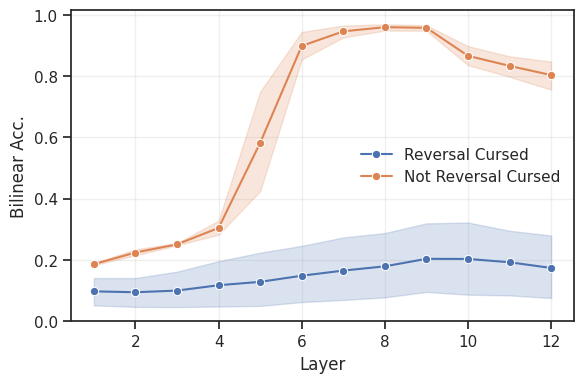

In [27]:
# Filter for overall relation and create lineplot
df_overall = df_bilinear[df_bilinear['relation'] == 'overall']
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_overall, x='layer', y='accuracy', hue='group', marker='o')
# plt.title('Accuracy by Layer for Overall Relation')
plt.xlabel('Layer')
plt.ylabel('Bilinear Acc.')
plt.legend(frameon=False)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

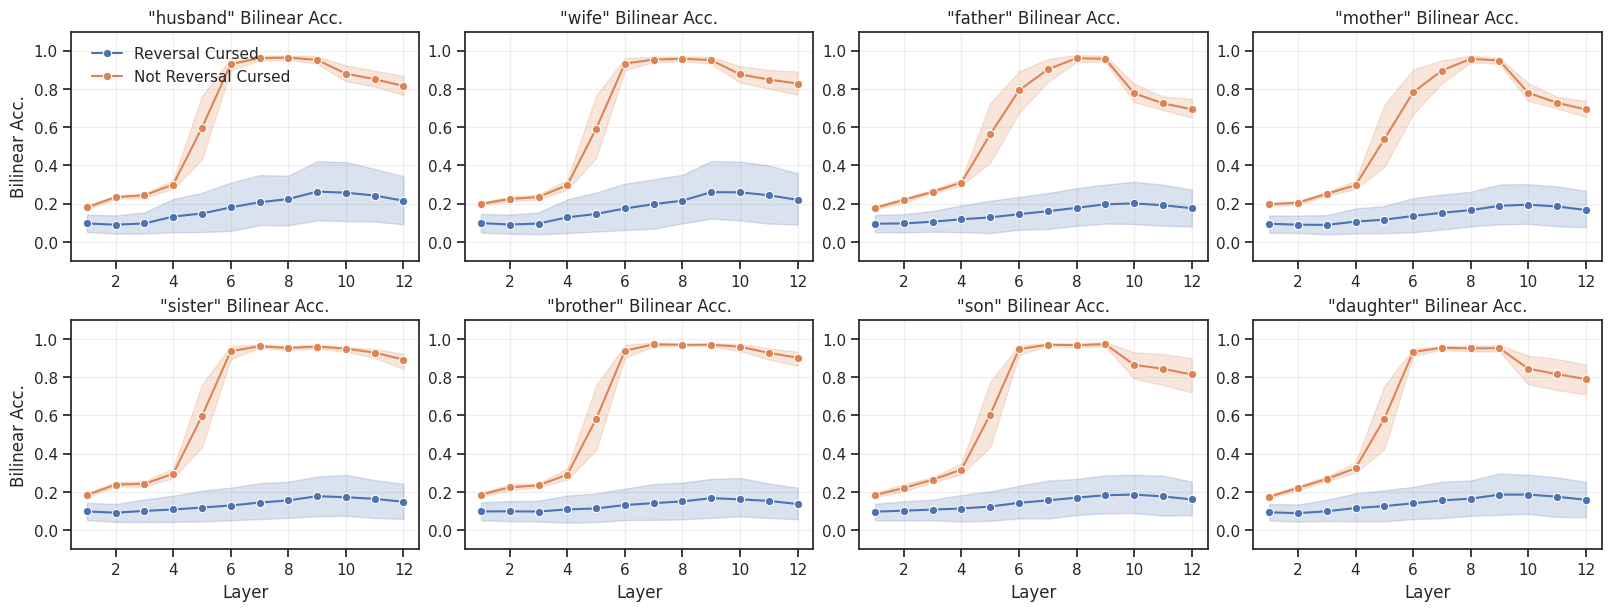

In [28]:
# Map weight decay keys to meaningful labels
rels = ["husband", "wife", "father", "mother", "sister", "brother", "son", "daughter"]
# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 6), constrained_layout=True)

for i, rel in enumerate(rels):
    ax = axes[i // 4, i % 4]
    rel_df = df_bilinear[df_bilinear['relation'] == rel]
    sns.lineplot(data=rel_df, x='layer', y='accuracy', ax=ax, hue='group', marker='o', legend=i==3)
    ax.set_title(f'"{rel}" Bilinear Acc.')
    
    # Only show x-label on bottom row
    if i // 4 == 1:
        ax.set_xlabel('Layer')
    else:
        ax.set_xlabel('')
    
    # Only show y-label on leftmost column
    if i % 4 == 0:
        ax.set_ylabel('Bilinear Acc.')
    else:
        ax.set_ylabel('')
        
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)

    if i == 3:
        ax.legend_.remove()
        handles, labels = ax.get_legend_handles_labels()
        
        fig.legend(
            handles, labels,
            loc='center left',
            bbox_to_anchor=(0.045, 0.9),
            frameon=False
        )
# plt.tight_layout()
plt.savefig("SM-rescal_acc_over_relations.pdf", bbox_inches='tight')

/tmp/ipykernel_52189/646236133.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


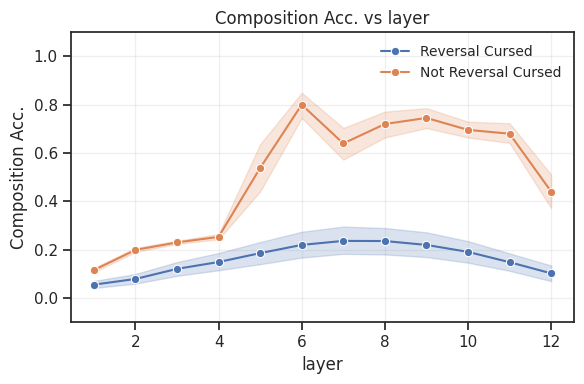

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
sns.lineplot(
    data=df_composition,
    x='layer',
    y='accuracy',
    ax=ax,
    hue='group',
    marker='o',
)

ax.legend(fontsize='10', frameon=False)
ax.set_title('Composition Acc. vs layer')
ax.set_xlabel('layer')
ax.set_ylabel('Composition Acc.')
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()


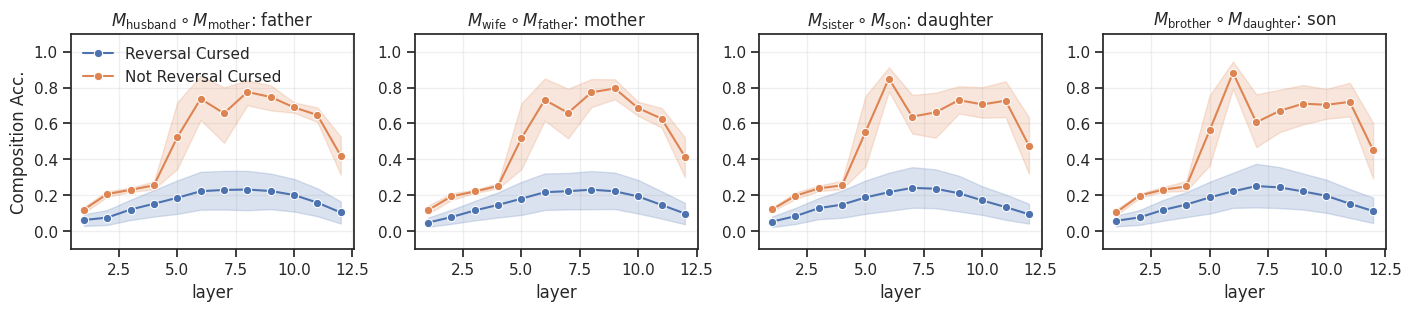

In [30]:
# Plot with the corrected data
sns.set_theme(style="ticks")

latex_expression = {"mother-husband": r"$ M_{\text{husband}} \circ M_{\text{mother}} $: father",
                    "father-wife": r"$M_{\text{wife}} \circ M_{\text{father}}$: mother",
                    "son-sister": r"$M_{\text{sister}} \circ M_{\text{son}}$: daughter",
                    "daughter-brother": r"$M_{\text{brother}} \circ M_{\text{daughter}} $: son"}

fig, axes = plt.subplots(1, 4, figsize=(14, 3), constrained_layout=True)
for i, rel in enumerate(df_composition.composition.unique()):
    ax = axes[i]
    rel_df = df_composition[df_composition['composition'] == rel]
    sns.lineplot(
        data=rel_df,
        x='layer',
        y='accuracy',
        ax=ax,
        hue='group',
        marker='o',
        legend=i==3
    )
    ax.set_title(f'{latex_expression[rel]}')
    ax.set_xlabel('layer')
    ax.set_ylabel('accuracy')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)
    # Only show y-label on leftmost column
    if i % 4 == 0:
        ax.set_ylabel('Composition Acc.')
    else:
        ax.set_ylabel('')
    if i == 3:
        ax.legend_.remove()
        handles, labels = ax.get_legend_handles_labels()
        
        fig.legend(
            handles, labels,
            loc='center left',
            bbox_to_anchor=(0.045, 0.8),
            frameon=False
        )

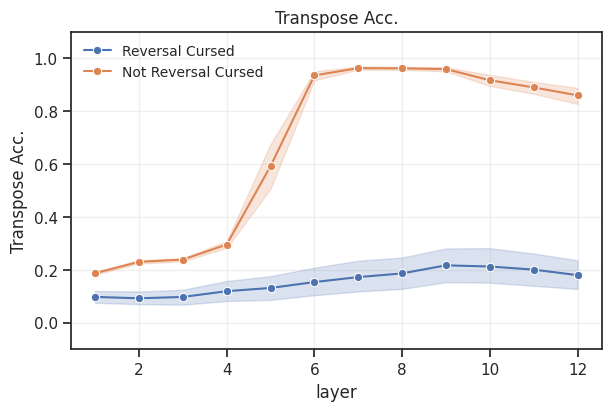

In [31]:
# Map weight decay keys to meaningful labels
rels = ["husband", "wife", "sister", "brother"]
# Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)

sns.lineplot(
    data=df_transpose,
    x='layer',
    y='transpose_accuracy',
    ax=ax,
    hue='group',
    marker='o',
)
ax.set_title(f'Transpose Acc.')
ax.set_xlabel('layer')
ax.set_ylabel('Transpose Acc.')
ax.legend(fontsize='10', frameon=False)
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

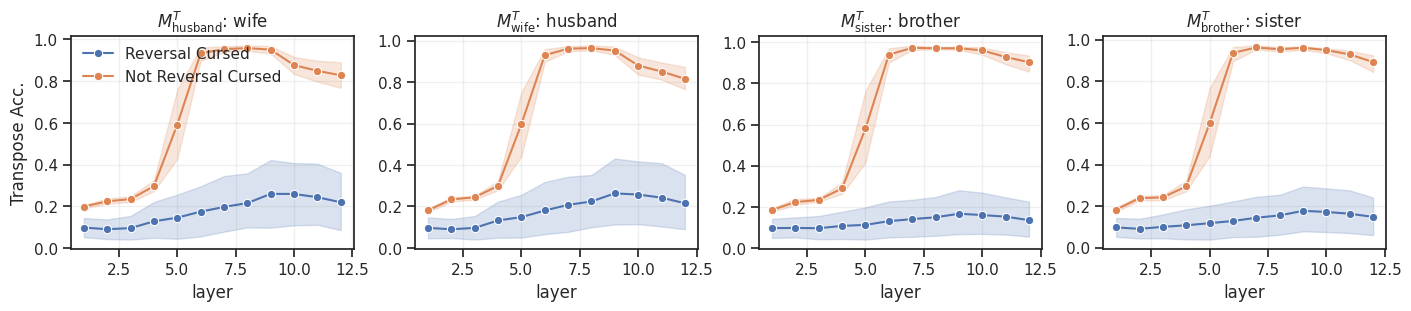

In [32]:
# Map weight decay keys to meaningful labels
rels = ["husband", "wife", "sister", "brother"]
# Plot
fig, axes = plt.subplots(1, 4, figsize=(14, 3), constrained_layout=True)
latex_expression = {"husband": r"$M_{\text{husband}}^T$: wife",
                    "wife": r"$M_{\text{wife}}^T$: husband",
                    "sister": r"$M_{\text{sister}}^T$: brother",
                    "brother": r"$M_{\text{brother}}^T$: sister"}

for i, rel in enumerate(rels):
    ax = axes[i]
    rel_df = df_transpose[df_transpose['relation'] == rel]
    sns.lineplot(
        data=rel_df,
        x='layer',
        y='transpose_accuracy',
        ax=ax,
        hue='group',
        marker='o',
        legend=i==3
    )
    ax.set_title(f'{latex_expression[rel]}')
    ax.set_xlabel('layer')
    ax.set_ylabel('accuracy')
    # ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)
    # Only show y-label on leftmost column
    if i % 4 == 0:
        ax.set_ylabel('Transpose Acc.')
    else:
        ax.set_ylabel('')
    if i == 3:
        ax.legend_.remove()
        handles, labels = ax.get_legend_handles_labels()
        
        fig.legend(
            handles, labels,
            loc='center left',
            bbox_to_anchor=(0.045, 0.8),
            frameon=False
        )

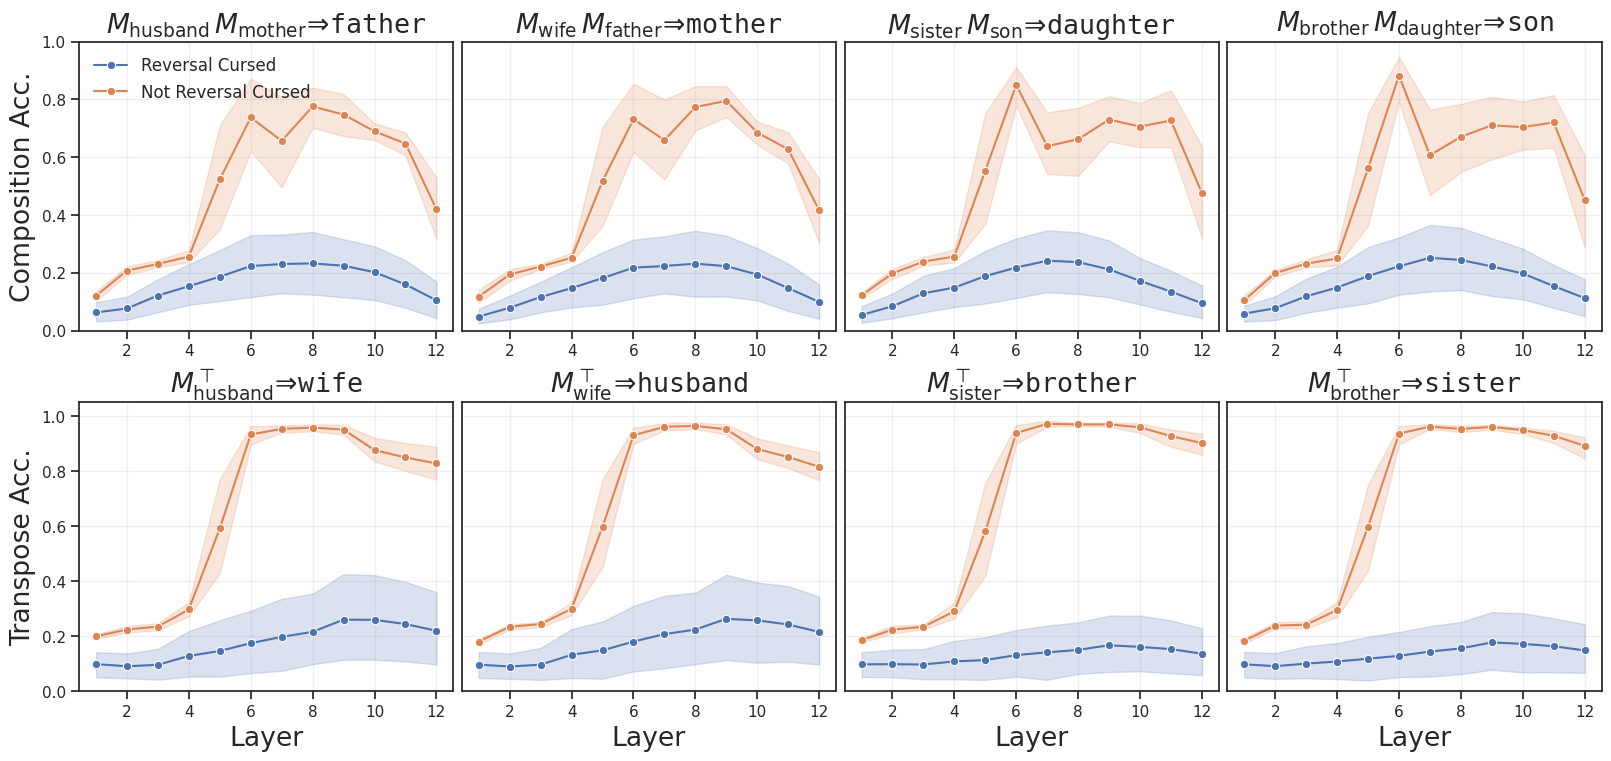

In [44]:
# Create a combined plot with composition and transpose figures
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), constrained_layout=True)

font_scale = 1.2

# Composition plots (top row)
latex_expression_comp = {
    "mother-husband": r"$M_{\text{husband}}\,M_{\text{mother}}\!\Rightarrow\!\mathtt{father}$",
    "father-wife": r"$M_{\text{wife}}\,M_{\text{father}}\!\Rightarrow\!\mathtt{mother}$",
    "son-sister": r"$M_{\text{sister}}\,M_{\text{son}}\!\Rightarrow\!\mathtt{daughter}$",
    "daughter-brother": r"$M_{\text{brother}}\,M_{\text{daughter}}\!\Rightarrow\!\mathtt{son}$",
}

comp_order = ["mother-husband", "father-wife", "son-sister", "daughter-brother"]
for i, rel in enumerate(comp_order):
    ax = axes[0, i]  # Top row
    rel_df = df_composition[df_composition['composition'] == rel]
    sns.lineplot(
        data=rel_df,
        x='layer',
        y='accuracy',
        ax=ax,
        hue='group',
        marker='o',
        legend=(i == 0)
    )
    ax.set_title(latex_expression_comp[rel], fontsize=16 * font_scale)
    ax.set_xlabel('', fontsize=12)  # Remove x-label for top row
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_ylabel('Composition Acc.', fontsize=16*font_scale)
        ax.legend(fontsize=12, loc="upper left", frameon=False)
    else:
        ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=11)
    if i != 0:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)

# Transpose plots (bottom row)
latex_expression_trans = {
    "husband": r"$M_{\text{husband}}^\top\!\Rightarrow\!\mathtt{wife}$",
    "wife": r"$M_{\text{wife}}^\top\!\Rightarrow\!\mathtt{husband}$",
    "sister": r"$M_{\text{sister}}^\top\!\Rightarrow\!\mathtt{brother}$",
    "brother": r"$M_{\text{brother}}^\top\!\Rightarrow\!\mathtt{sister}$",
}

rels_trans = ["husband", "wife", "sister", "brother"]
for i, rel in enumerate(rels_trans):
    ax = axes[1, i]  # Bottom row
    rel_df = df_transpose[df_transpose['relation'] == rel]
    sns.lineplot(
        data=rel_df,
        x='layer',
        y='transpose_accuracy',
        ax=ax,
        hue='group',
        marker='o',
        legend=False
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(latex_expression_trans[rel], fontsize=16*font_scale)
    ax.set_xlabel('Layer', fontsize=16*font_scale)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_ylabel('Transpose Acc.', fontsize=16*font_scale)
    else:
        ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=11)
    if i != 0:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)

# plt.tight_layout()
plt.savefig("rescal_composition_transpose.pdf", bbox_inches='tight')
